In [17]:

from dotenv import load_dotenv
from tavily import TavilyClient
load_dotenv()
import os 
Tavily_Api = os.getenv("TAVILY_API_KEY")
OpenAI_Api = os.getenv("OPEN_AI_API_KEY")
grok_api = os.getenv("GROK_API")


tavily_client = TavilyClient(api_key=Tavily_Api)




In [18]:
import json
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

class ResearcherAIAgent:
    def __init__(self, name):
        self.name = name
        self.chat_model = ChatGroq(api_key=grok_api, model="openai/gpt-oss-120b", temperature=0.5, max_tokens=1024)
    def generate_response(self, query, critic_score=None, previous_answer=None,context=None):
        prompt = f"""
You are a research agent.
Context: {context}
Query: {query}

Previous Answer: {previous_answer}

Critic Score: {critic_score}

Instructions:
1. Decide if external research is needed.
2. If needed, say research_needed = true and add the stuff you need to research in the input field.
3. Improve the answer if critic_score < 5.
4. Return ONLY valid JSON.

Format:
{{
    "research_needed": true/false,
    "input":""
    "result": "final improved answer"
}}
"""

        response = self.chat_model.invoke(prompt).content

        try:
            data =  json.loads(response)
            input = data.get("input","")
            
            if "research_needed" in data:
                context = tavily_client.search(input, top_k=3)
                response = self.chat_model.invoke(prompt).content
                
                return response
                
                 
        except:
            print("⚠️ JSON parsing failed")
            return {
                "research_needed": False,
                "result": response
            }

    def run(self, query):
        answer = None
        critic_score = None

        for iteration in range(3):  
            response = self.generate_response(query, critic_score, answer)

            answer = response["result"]
            print(f"\n🧠 Iteration {iteration+1} Answer:\n", answer)

            critic_score = int(input("Rate (1–10): "))

            if critic_score >= 5:
                break

        return answer

In [135]:
from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain.messages import SystemMessage,AnyMessage,HumanMessage
from typing import TypedDict ,Literal,Annotated,List
import operator


llm = ChatGroq(api_key=grok_api, model="openai/gpt-oss-120b", temperature=0.5, max_tokens=1024)
@tool
def search_tool(query: str) -> str:
    """Searches for relevant information using Tavily."""
    results = tavily_client.search(query, top_k=3)
    print(f"🔍 Search results for '{query}':\n", results,"\n\n")
    return results

tools = [search_tool]
model_with_tools = llm.bind_tools(tools)


    

In [153]:
class ResearchState(TypedDict, total=False):
    messages: Annotated[list, operator.add]
    query: str
    docs: List[str] | None
    answer: str | None
    score: float | None
    iteration: int

In [154]:
def llm_call(state: ResearchState) -> ResearchState:
    response = model_with_tools.invoke([SystemMessage(content="You are a helpful assistant."), *state["messages"]])
    return {
        "messages": state["messages"] + [response],
        "llm_call": state.get("llm_call",0) + 1
    }
    
#Planner Node
def planner_node(state: ResearchState) -> ResearchState:
   
    prompt = f"""
    Decide if this query needs external search.

    Query: {state['query']}

    Respond with either:
    - "search"
    - "direct"
    """
    response = llm.invoke([SystemMessage(content = "You are a Planner"),HumanMessage(content=prompt)])
    decision = response.content.strip().lower()
    return {
        "messages": [response],
        "decision": decision
    }
    
tools_by_name = {"search": search_tool}
#tool 
def tool_node(state: ResearchState):
    last_msg = state["messages"][-1]

    results = []

    for tool_call in last_msg.tool_calls:
        tool_fn = tools_by_name[tool_call["name"]]
        observation = tool_fn.invoke(tool_call["args"])
        results.extend(observation)

    return {"docs": results}

## LLM TOOL CALLING RESPONSE 
{
  "tool_calls": [
    {
      "name": "tool_name",
      "arguments": { ... }
    }
  ]
}

In [162]:

def generation_node(state: ResearchState):
    docs_text = "\n".join(state.get("docs",[]))
    prompt = f"""
    Answer the question using the following context:

    Context:
    {docs_text}

    Question:
    {state["query"]}
    """
    response = llm.invoke([SystemMessage(content="You are a Research Agent"),HumanMessage(content=prompt)])
    return {"answer": response.content, "messages": [response]
            }


In [163]:
def evaluate_node(state: ResearchState):
    prompt = f"""
    Evaluate the quality of this answer (0 to 1):

    Question: {state['query']}
    Answer: {state['answer']}

    Consider:
    - correctness
    - completeness
    - clarity

    Return only a float score.
    """
    response = llm.invoke([SystemMessage(content="You are a Critic"),HumanMessage(content=prompt)]) 
    try:
        score = float(response.content.strip())
    except:
        score = 0.0
    return {"score": score, "messages": [response]}

    

In [164]:
from langgraph.graph import StateGraph,START,END
def should_continue(state:ResearchState)-> Literal["retry", END]:
    if state["score"] <= 0.8:
        return "retry"
    else:
        return END
def route_plan(state: ResearchState) -> Literal["tool", "generate"]:
    last = state["messages"][-1].content.lower()
    if "search" in last:
        return "tool"
    return "generate" 

In [165]:
graph = StateGraph(ResearchState)
graph.add_node("planner", planner_node)
graph.add_node("tool", tool_node)   
graph.add_node("generate", generation_node)
graph.add_node("evaluate", evaluate_node)   

graph.add_edge(START,"planner")
graph.add_conditional_edges("planner", route_plan, {"tool": "tool", "generate": "generate"})
graph.add_edge("tool","generate")
graph.add_edge("generate","evaluate")
graph.add_conditional_edges("evaluate", should_continue, {"retry": "planner", END: END})
agent = graph.compile()

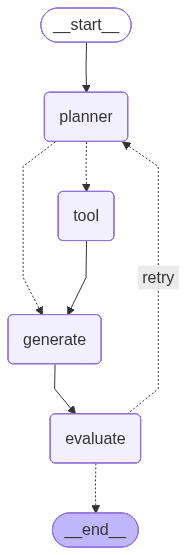

In [166]:
agent

In [167]:
result = agent.invoke({
    "query": "What is RAG in AI?",
    "messages": [],
    "docs": [],
    "answer": "",
    "score": 0.0,
    "iteration": 0
})

print(result["answer"])

**RAG (Retrieval‑Augmented Generation)** is a hybrid AI approach that combines two key steps:

1. **Retrieval** – The system first searches an external knowledge source (e.g., a document database, web index, or knowledge base) to pull relevant passages or facts that are pertinent to the user’s query.
2. **Generation** – A generative language model (such as GPT, T5, LLaMA, etc.) then uses those retrieved pieces of information as context to produce a response that is both fluent and grounded in factual data.

### Why RAG is used
- **Improved factuality**: By grounding the model’s output in up‑to‑date external documents, the risk of “hallucinations” (making up information) is reduced.
- **Scalability of knowledge**: The model itself can stay relatively small, while the knowledge base can be expanded or updated independently without retraining the entire model.
- **Dynamic knowledge**: The system can incorporate the latest information (e.g., news articles, recent research) simply by updati

In [ ]:
result = agent.invoke({
    "query": "latest developments in AI 2026",
})


In [171]:
print(result['answer'])

**Key AI Milestones in 2026 (as of April 2026)**  

Below is a snapshot of the most‑significant technical, commercial, and policy developments that have shaped the field of artificial intelligence over the past year.  The list is organized by theme and includes both widely‑reported breakthroughs and emerging trends that are already influencing research and industry.

---

## 1. Foundation‑Model Evolution  

| Development | What it is | Why it matters |
|-------------|------------|----------------|
| **GPT‑5 (OpenAI)** | A 1‑trillion‑parameter, sparsely‑activated transformer that can run inference on a single H200 GPU with dynamic routing. | Demonstrates *cost‑effective* trillion‑scale reasoning, improves zero‑shot performance on complex chain‑of‑thought tasks, and introduces “self‑debugging” loops that reduce hallucinations by ~30 % compared with GPT‑4. |
| **Gemini 2 (Google DeepMind)** | Multimodal model (text + image + video + audio) with 2 trillion parameters, trained on a mixture 